# Data Validation Techniques & Overfitting/Underfitting
## A Finance Domain Case Study — Loan Default Prediction



In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import (train_test_split, KFold, StratifiedKFold,
    TimeSeriesSplit, cross_val_score, learning_curve, validation_curve)
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

np.random.seed(42)
plt.rcParams["figure.dpi"] = 100


## 1. Dataset — Loan Default Prediction (Finance Domain)


In [ ]:
n = 4000
age               = np.random.randint(21, 65, n)
income             = np.random.gamma(9, 5000, n)              # annual income
loan_amount        = np.random.gamma(6, 4000, n)
credit_score       = np.clip(np.random.normal(650, 90, n), 300, 850)
dti                = np.clip(np.random.gamma(3, 6, n), 0, 90)  # debt-to-income %
employment_years   = np.clip(np.random.gamma(2, 3, n), 0, 40)
num_prev_defaults  = np.random.poisson(0.3, n)
loan_term_months   = np.random.choice([12, 24, 36, 48, 60], n)
application_order  = np.arange(n)  # chronological application order

# Default probability is a nonlinear combination of risk factors -- similar to a real credit-risk model
risk = (-0.010*(credit_score-650) + 0.05*dti + 0.00006*loan_amount
        - 0.00003*income + 0.9*num_prev_defaults - 0.06*employment_years
        + 0.15*(loan_term_months/12))
z = risk - 3.5 + np.random.randn(n)*0.6
prob_default = 1/(1+np.exp(-z))
default = (prob_default > np.random.uniform(0,1,n)).astype(int)

df = pd.DataFrame({
    "Age": age, "Income": income.round(0), "Loan_Amount": loan_amount.round(0),
    "Credit_Score": credit_score.round(0), "DTI_Ratio": dti.round(1),
    "Employment_Years": employment_years.round(1), "Num_Previous_Defaults": num_prev_defaults,
    "Loan_Term_Months": loan_term_months, "Application_Order": application_order,
    "Default": default
})

X = df.drop(columns=["Default", "Application_Order"])
y = df["Default"]

print("Dataset shape:", df.shape)
print("Default rate:", round(y.mean(), 4))
df.head()


Dataset shape: (4000, 10)
Default rate: 0.176


,Age,Income,Loan_Amount,Credit_Score,DTI_Ratio,Employment_Years,Num_Previous_Defaults,Loan_Term_Months,Application_Order,Default
0,59,44601.0,30950.0,658.0,5.9,8.9,0,60,0,0
1,49,32492.0,23169.0,633.0,6.9,5.0,0,36,1,0
2,35,49788.0,26494.0,498.0,11.3,2.1,0,12,2,0
3,63,67412.0,22282.0,581.0,33.4,5.0,0,60,3,0
4,28,53630.0,28172.0,672.0,11.0,5.4,1,12,4,0


## 2. Data Validation Techniques


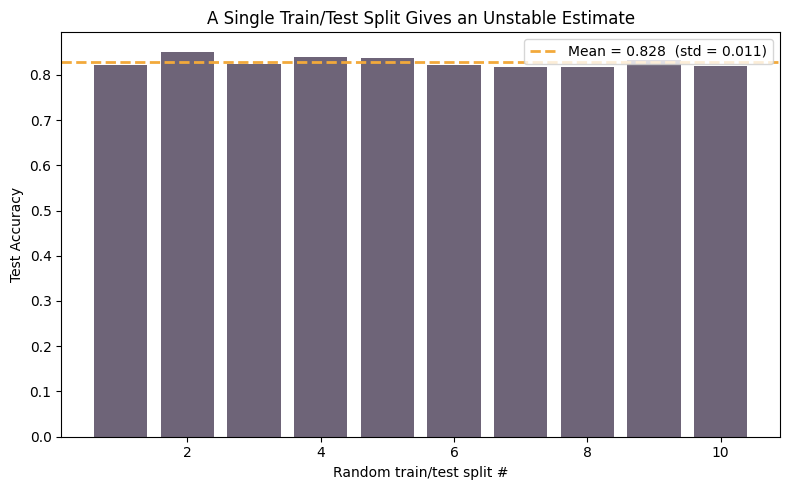

In [ ]:
single_split_scores = []
for rs in range(10):
    Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.2, random_state=rs)
    clf = DecisionTreeClassifier(max_depth=5, random_state=42)
    clf.fit(Xtr, ytr)
    single_split_scores.append(accuracy_score(yte, clf.predict(Xte)))

plt.figure(figsize=(8,5))
plt.bar(range(1,11), single_split_scores, color="#6E6478")
plt.axhline(np.mean(single_split_scores), color="#F2A93B", linestyle="--", linewidth=2,
            label=f"Mean = {np.mean(single_split_scores):.3f}  (std = {np.std(single_split_scores):.3f})")
plt.xlabel("Random train/test split #")
plt.ylabel("Test Accuracy")
plt.title("A Single Train/Test Split Gives an Unstable Estimate")
plt.legend()
plt.tight_layout()
plt.show()


### 2.3 TimeSeriesSplit — Validation for Chronological Finance Data



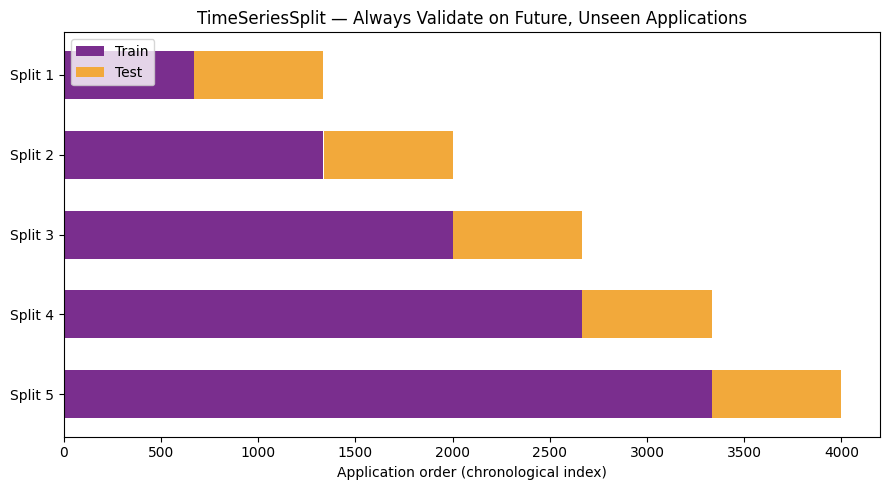

In [ ]:
tscv = TimeSeriesSplit(n_splits=5)

plt.figure(figsize=(9,5))
for i, (train_idx, test_idx) in enumerate(tscv.split(X)):
    plt.barh(i, train_idx.max()-train_idx.min(), left=train_idx.min(), color="#7A2E8E", height=0.6,
              label="Train" if i==0 else "")
    plt.barh(i, test_idx.max()-test_idx.min(), left=test_idx.min(), color="#F2A93B", height=0.6,
              label="Test" if i==0 else "")
plt.yticks(range(5), [f"Split {i+1}" for i in range(5)])
plt.xlabel("Application order (chronological index)")
plt.title("TimeSeriesSplit — Always Validate on Future, Unseen Applications")
plt.legend(loc="upper left")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


## 3. Overfitting vs. Underfitting

### 3.1 Validation Curve — Decision Tree Depth


Best depth: 4  | validation accuracy: 0.8282


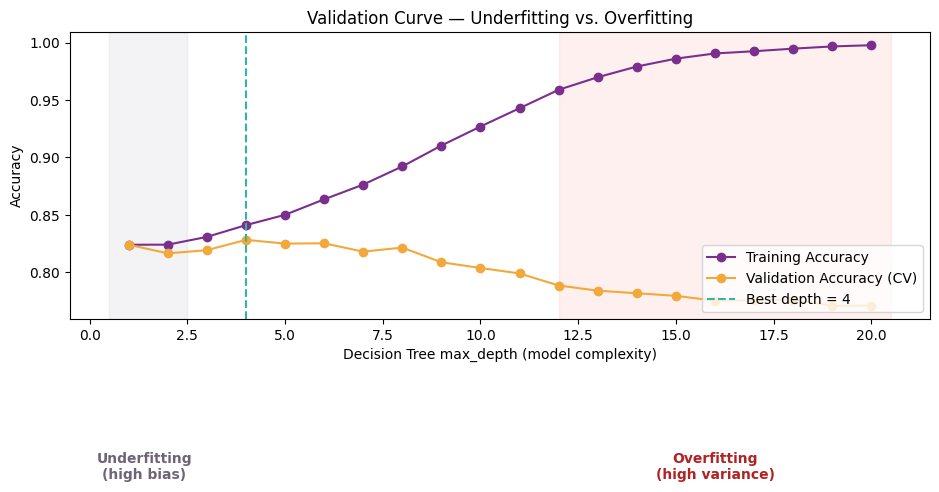

In [ ]:
depths = range(1, 21)
train_scores, val_scores = validation_curve(
    DecisionTreeClassifier(random_state=42), X, y, param_name="max_depth",
    param_range=depths, cv=StratifiedKFold(5, shuffle=True, random_state=42), scoring="accuracy"
)
train_mean, val_mean = train_scores.mean(axis=1), val_scores.mean(axis=1)
best_depth = list(depths)[np.argmax(val_mean)]
print("Best depth:", best_depth, " | validation accuracy:", round(val_mean.max(), 4))

plt.figure(figsize=(9.5,6))
plt.plot(depths, train_mean, "o-", color="#7A2E8E", label="Training Accuracy")
plt.plot(depths, val_mean, "o-", color="#F2A93B", label="Validation Accuracy (CV)")
plt.axvline(best_depth, color="#2FB6A6", linestyle="--", label=f"Best depth = {best_depth}")
plt.axvspan(0.5, 2.5, color="#6E6478", alpha=0.08)
plt.axvspan(12, 20.5, color="red", alpha=0.06)
plt.text(1.4, 0.62, "Underfitting\n(high bias)", ha="center", color="#6E6478", weight="bold")
plt.text(16, 0.62, "Overfitting\n(high variance)", ha="center", color="firebrick", weight="bold")
plt.xlabel("Decision Tree max_depth (model complexity)")
plt.ylabel("Accuracy")
plt.title("Validation Curve — Underfitting vs. Overfitting")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()


## 4. Technique to Reduce Overfitting / Underfitting

### 4.1 Regularization (Logistic Regression)


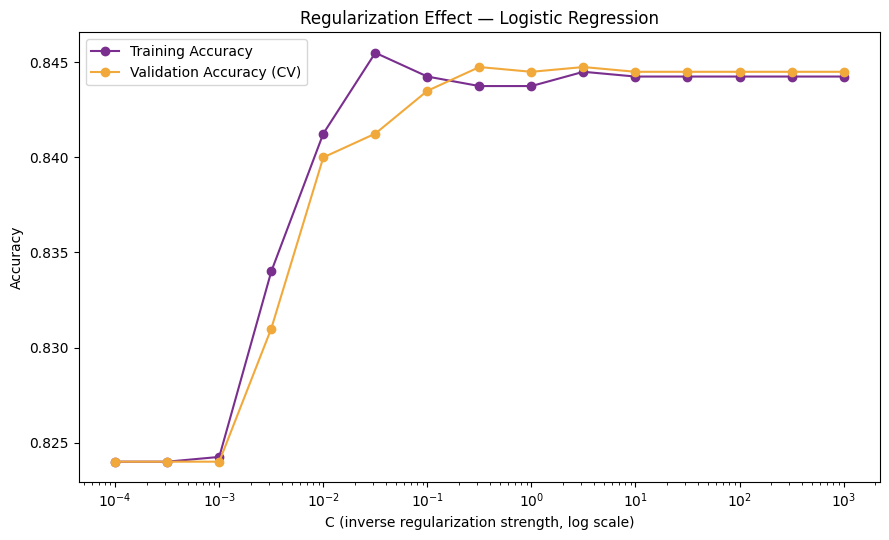

In [ ]:
Xs = StandardScaler().fit_transform(X)
C_values = np.logspace(-4, 3, 15)
lr_train, lr_val = [], []
for C in C_values:
    scores = cross_val_score(LogisticRegression(C=C, max_iter=2000), Xs, y,
                              cv=StratifiedKFold(5, shuffle=True, random_state=42), scoring="accuracy")
    m = LogisticRegression(C=C, max_iter=2000).fit(Xs, y)
    lr_train.append(accuracy_score(y, m.predict(Xs)))
    lr_val.append(scores.mean())

plt.figure(figsize=(9,5.5))
plt.semilogx(C_values, lr_train, "o-", color="#7A2E8E", label="Training Accuracy")
plt.semilogx(C_values, lr_val, "o-", color="#F2A93B", label="Validation Accuracy (CV)")
plt.xlabel("C (inverse regularization strength, log scale)")
plt.ylabel("Accuracy")
plt.title("Regularization Effect — Logistic Regression")
plt.legend()
plt.tight_layout()
plt.show()


In [ ]:
summary = pd.DataFrame({
    "Technique": ["Regularization (Logistic Reg"],
    "Train_Acc": [rf_train]
    "Val_Acc":   [rf_val],
})
summary["Gap"] = (summary["Train_Acc"] - summary["Val_Acc"]).round(4)
summary


NameError: name 'rf_train' is not defined